<a href="https://colab.research.google.com/github/Markint86/03MIAR----Algoritmos-de-Optimizacion/blob/main/Copia_de_Seminario_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Marcos Quintas Pérez   <br>
Nombre y Apellidos: Domingo Jiménez Liébana   <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---2019/tree/master/SEMINARIO<br>
Problema:
> 1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de La Liga<br>
>3. Combinar cifras y operaciones

Descripción del problema:(copiar enunciado)

....

(*) La respuesta es obligatoria





                                        

**Organizar sesiones de doblaje**

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:

Número de actores: 10

Número de tomas : 30

Actores/Tomas : https://bit.ly/36D8IuK

- 1 indica que el actor participa en la toma
- 0 en caso contrario

### (*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



### ¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




Respuesta

Primero calcularemos el numero de posibilidades (numero de elementos del espacio de soluciones) $\textbf{teniendo en cuenta las restricciones}$. Con las restricciones, sabemos que el numero maximo de tomas a grabar por dia son 6 tomas. Por lo tanto podemos deducir que el numero de dias a distribuir todas las tomas debe ser 5, dado que es el numero minimo de dias en los que se pueden grabar las 30 tomas, y mas dias de grabacion supondrian un coste mayor dado que se les paga a los actores por cada dia que van al set de grabacion. El problema se debe centrar entonces en como distribuir las tomas en esos 5 dias cumpliendo la restriccion de 6 tomas maximas por dia.

Entonces con esas restricciones sabemos que si el primer dia asignamos 6 tomas de las 30, al segundo debemos asignar otras 6 tomas de las 24 restantes, al tercero 6 de las 18 restantes, al cuarto 6 de las 12 restantes y al ultimo las 6 que queden por asignar. De esta forma tenemos que el numero posible de soluciones teniendo en cuenta todas las combinaciones es


$$

\binom{30}{6}\binom{24}{6}\binom{18}{6}\binom{12}{6}\binom{6}{6} \sim 1.37 \cdot 10^{18}

$$


Que vemos es un espacio de soluciones inmenso. R

$\textbf{Sin tener en cuenta las restricciones}$, el numero posible de soluciones si dejamos que las tomas se asignen de nuevo en los 5 dias entonces el numero de posibilidades es

$$

5^{30} \sim 9.31 \cdot 10^{20}

$$

que, como es de esperar, es bastante mayor que con las restricciones impuestas al problema.

### Modelo para el espacio de soluciones<br>
### (*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


Respuesta

Dada su simplidad y facilidad de representacion y manipulacion, la primera solucion que propusimos, y ls cual usamos para implementar el algoritmo de fuerza bruta y el algoritmo genetico, se trata de una tupla 

$$
    (d_1, d_2, d_3, ... , d_{30})
$$

donde cada elemento $d_i$ representa el dia en el que se grabo la toma i. Por lo tanto $d_i \in [0,1,2,3,4,5]$ son los valores posibles de cada componente. Vemos que empezamos contando por 0, de forma que al dia 1 se le asigna un 0, al dia 2 se le asigna un 1, etc

Despues de realizar el algoritmo de fuerza bruta y el algoritmo genetico (los cuales se explicaran mas adelante), algoritmos para los cuales esta estuctura de solucion es muy efectiva, planteamos la posibilidad de mejorar tambien la fuerza bruta buscando un optimo mediante un algoritmo exacto, y desarrollamos un algoritmo de branch and bound con DFS y memorizacion, el cual explicaremos despues de presentar el algoritmo genetico. Para la realizacion de este algortimo, por constrains de la propia implementacion, decidimos usar otra estructura de solucion, que aun no siendo la misma, es similar a la presentada arriba, y que consiste en lo siguiente 

### Según el modelo para el espacio de soluciones<br>
### (*)¿Cual es la función objetivo?

### (*)¿Es un problema de maximización o minimización?

Respuesta

Teniendo en cuenta que los actores cobran lo mismo por cada dia que van independientemente del numero de tomas que se graban ese dia, le podemos asignar una unidad de coste a cada actor que vaya un dia, de forma que el coste total de cada actor es el numero de dias que fue al set de rodaje porque le correspondia grabar alguna toma en la que aparecia. Por lo tanto nuestra funcion objetivo es

$$
f = \sum_{}^{}\text{(dias que va cada actor)}

$$

donde al calcular el valor de la funcion objetivo dada una solucion determinada, debemos tener en cuenta la restriccion de que si una toma se graba un dia, todos los actores que graban dicha toma deben coincidir ese dia en el set de rodaje.

Aqui lo que queremos es minimizar el coste de planificacion dada por la funcion objetivo, que para el caso tambien podemos denominar funcion de coste, por lo que claramente se trata de un $\textbf{problema de minimizacion}$.

### Diseña un algoritmo para resolver el problema por fuerza bruta

Respuesta

Ahora presentamos el algoritmo de fuerza bruta, que se basa en explorar todo el espacio de soluciones para encontrar la solucion optima-solucion de menor coste en nuestro caso- entre las soluciones validas

In [26]:
# Solucion (d1, d2, d3, ..., d30) ---> tupla con los dias en los que se rueda cada toma 


#Matriz A completa de tomas de cada agente

A =[[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

Definimos la funcion que calcula el coste a partir de una solucion schedule y una matriz A de tomas y agentes dada. Tambien definimos una funcion que nos comprueba si una solucion dada solucion es valida. Estas funciones las reutilizaremos despues en el algoritmo genetico

In [27]:

def talent_cost(schedule, A, num_days=5):
    """
    schedule[s] = día de la toma s
    A[s][a] = 1 si actor a aparece en toma s (tomas en filas, actores en columnas)
    """
    num_scenes = len(A)  # número de tomas (filas)
    num_actors = len(A[0])  # número de actores (columnas)

    total_cost = 0

    for a in range(num_actors):
        worked_days = set()

        for s in range(num_scenes):
            if A[s][a] == 1:  
                worked_days.add(schedule[s])

        total_cost += len(worked_days)

    return total_cost


def is_valid_schedule(solucion, max_tomas_por_dia=6):
    """
    Verifica si una solución es válida según la restricción de máximo de tomas por día.
    
    Args:
        solucion: Lista donde cada índice i representa la toma i, 
                  y el valor es el día en que se grabó
        max_tomas_por_dia: Número máximo de tomas permitidas por día (default: 6)
    
    Returns:
        True si la solución es válida, False en caso contrario
    """
    # Contar cuántas tomas hay en cada día
    conteo_dias = {}
    
    for dia in solucion:
        if dia in conteo_dias:
            conteo_dias[dia] += 1
        else:
            conteo_dias[dia] = 1
    
    # Verificar que ningún día tenga más de max_tomas_por_dia
    for dia, num_tomas in conteo_dias.items():
        if num_tomas > max_tomas_por_dia:
            return False
    
    return True

In [28]:
is_valid_schedule([1,0,0,1,0,0,0,1], max_tomas_por_dia=6) #Ejemplo, solucion valida

True

Dada la inmensidad del espacio de soluciones, vamos a implementar el algoritmo de fuerza bruta sobre un subproblema del problema inicial, porque de otra manera no seriamos capaces de terminar de ejecutarlo. Recordar que el espacio de soluciones original es del orden de $10^{20}$. Entonces nos vamos a quedar con las primeras 12 tomas (filas) de la matriz original para poder hacer que el algoritmo de fuerza bruta termine en un tiempo razonable. Como mantenemos la restriccion de las 6 tomas por dia, todas las tomas se van a distribuir en 2 dias

In [29]:
import itertools

#usamos la funcion itertools para generar todo el espacio de soluciones
def generate_combinations(longitud):
    """
    Genera todas las combinaciones posibles de 0s y 1s para una longitud dada
    """
    return itertools.product([0, 1], repeat=longitud)

def brute_force(A):
    # En nuestro caso la longitud es 12
    longitud = len(A)

    # Generar todas las combinaciones
    Soluciones = generate_combinations(longitud)

    min_coste = float('inf') #inicializamos la variable que nos va a ir dando el coste minimo

    # Iterar sobre todas las posibles soluciones
    for S in Soluciones:
        if is_valid_schedule(S): #checkeamos si es solucion valida porque en ninguno de los 2 dias se graban mas de 6 tomas
            Coste = talent_cost(S, A, num_days=2)
            if Coste < min_coste:   #calculamos coste y vemos si mejora el mejor actual
                solucion = S
                min_coste = Coste

    return solucion, min_coste



Aplicamos el algoritmo de fuerza bruta sobre el dataset reducido de 12 tomas

In [30]:
B = A[0:12][:] #matriz de tomas-actores reducido

In [31]:
B

[[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
 [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
 [1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0],
 [1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]]

El algoritmo da como como resultado en este caso

In [32]:
#Aplicamos el algoritmo de fuerza bruta
Solucion, min_coste = brute_force(B) 

print(f"La solucion es: {Solucion} con coste total {min_coste}")

La solucion es: (0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1) con coste total 14


En este caso sencillo vemos como lo solucion es facilmente interpretable con esta estructura de solucion. Las primeras 5 tomas se asignan al dia 1 junto con la toma 9. Las 6 restantes se asignan al dia 2 de grabacion. Sin embargo hemos tenido que usar un problema reducido para poder ejecutar el algoritmo en tiempo razonable, lo cual muestra la clara limitacion que supone un algoritmo como el de fuerza bruta, que tiene que explorar todo el espacio de soluciones para encontrar la solucion. En los siguientes apartados veremos dos implemmentaciones de algoritmos, uno genetico otro de branch and bound, que nos permiten resolver el problema completo en un tiempo razonable obteniendo soluciones optimas. 

Calcula la complejidad del algoritmo por fuerza bruta

Respuesta

Teniendo en cuenta las operaciones elementales, donde cada llamada a una funcion externa se considera como operacion elemental, la complejidad de nuestro algoritmo de fuerza bruta para este caso particular es $O(2^n)$, donde n es el numero de tomas. Es decir, es el orden de complejidad de explorar el numero total de posilbles soluciones del espacio de soluciones para este problema reducido. Como vemos es exponencial incluso en este caso reducido.

### (*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

Respuesta

## Branch & Bound

### Por qué Branch & Bound

Hemos decidido utilizar Branch & Bound porque consideramos que se adapta muy bien al problema si lo que queremos es buscar una solución optima. 

Al final, es como el algoritmo de fuerza bruta pero vamos podando ramas que sabemos que no van a mejorar la mejor solución encontrada hasta el momento. Esto es prácticamente lo más importante ya que el número de combinaciones posibles es gigante y si no realizamos podas que reduzcan mucho la exploración de combinaciones, no tendrá sentido.

Sin centrarnos en la complejidad, tenemos claro que el Branch & Bound mejora al algoritmo de fuerza bruta en cuanto a tiempo ya que con las podas, conseguimos no explorar el 100% de las posibles soluciones por lo que el tiempo en todos los casos, será menor.

Reducir el tiempo un poco no es suficiente, lo que necesitamos es conseguir podar lo suficiente para poder conseguir un tiempo viable, es por ello que en nuestro algoritmo Branch & Bound realizamos 4 podas distintas y lo combinamos con selección de toma con *fail-first* y ordenación de días. Todo esto, lo explicaremos a continuación.

### Recorrido del árbol

El recorrido del árbol se realiza de la siguiente manera:
1. **Selección de toma (fail-first)**: En cada nodo, se elige la toma pendiente más difícil de colocar, es decir, la que tiene el peor mejor caso (la que, en el mejor día posible, incrementa más el coste). Esto se hace para intentar podar ramas malas cuanto antes.

2. **Ordenación de días:** Una vez seleccionada la toma, se prueban los días posibles para colocarla. Los días se ordenan según el incremento de actores que supondría añadir la toma: primero se prueba el día donde menos incrementa el coste, luego el siguiente, y así sucesivamente.

3. **Recursividad y backtracking:** Para cada combinación toma-día, se asigna la toma al día, se actualiza el estado y se llama recursivamente al siguiente nivel (con las tomas restantes). Tras explorar esa rama, se asigna la toma a un nuevo día y se vuelve a llamar recursivamente al siguiente nivel. Al probar la toma con todos los días, se deshace la asignación (backtrack) para probar otras opciones.

### Solución inicial

Primero, se obtiene una solución inicial usando el algoritmo greedy y se mejora con swaps (intercambios locales). Esto da un coste inicial que servirá como cota superior para podar ramas del árbol de búsqueda.

### Podas utilizadas

Para evitar explorar ramas inútiles, se aplican varias podas:

- Poda por coste actual: Si el coste actual ya es igual o peor que la mejor solución encontrada, se descarta la rama.
- Poda por cota inferior (lower bound): Se calcula una estimación optimista del mejor coste posible desde el estado actual (asumismos que como mínimo, debe haber una toma por cada día vacío). Si el coste actual, más el número de días vacíos es peor que la mejor solución, se poda la rama.
- Poda por memoización: Si ya se ha visitado el mismo estado (misma distribución de tomas y actores) con un coste igual o mejor, no se explora de nuevo.
- Poda por simetría: Los días son indistinguibles, así que si ya se ha probado asignar una toma a un día vacío, no se prueba en otros días vacíos ya que generarían las mismas combinaciones (en el mismo nivel).

### Heurística First-Fail

Para acelerar la poda, se usa la heurística fail-first: en cada paso, se elige la toma más difícil de colocar (la que, en el mejor caso, incrementa más el coste). Así, si una rama va a fallar, lo hace antes y se poda antes.

### Ordenación de días

Al intentar colocar una toma, se prueban primero los días donde menos incrementa el coste, para encontrar buenas soluciones pronto y así podar más ramas después.

### Garantía de optimalidad

Como solo se podan ramas cuando es seguro que no pueden mejorar la mejor solución, el algoritmo garantiza encontrar la solución óptima.

### Resumen

El algoritmo Branch and Bound explora el árbol de asignaciones posibles, pero gracias a la solución inicial y a las podas inteligentes (coste, cota inferior, memoización, simetría y fail-first), evita explorar la mayoría de ramas, encontrando la solución óptima de forma mucho más eficiente que la fuerza bruta.

### Estructuras de datos

#### Input
La matriz original es una matriz de 1s y 0s con filas que corresponden a las tomas y 10 columnas que corresponden a los actores. Un 1, indica que el actor trabaja en esa toma y un 0 indica que no trabaja.

Para hacer esta matriz más óptima, pasaremos a utilizar **bitmasks**. Una bitmask es un conjunto de bits (0 ó 1) que es la unidad mínima que puede gestionar un ordenador. Cada toma será una bitmask, es decir, un conjunto de bits en el que el bit con la posición uno corresponde al actor 1, el segundo bit al actor 2 y así sucesivamente.

Por tanto, la matriz original pasa a ser un vector de bitmasks:
```python
[
    0bx0000011111,
    0bx0000011100,
    0bx0001010010,
    0bx0011000011,
    0bx0010001010,
    0bx0000011011,
    0bx0000011011,
    0bx0000100011,
    0bx0000001011,
    0bx0100100011,
    0bx0010010111,
    0bx0000101111,
    0bx0000011001,
    0bx0000100101,
    0bx0001000011,
    0bx1000001000,
    0bx0000000101,
    0bx0000100100,
    0bx0000000101,
    0bx0000011101,
    0bx0010100000,
    0bx0000001111,
    0bx0000000101,
    0bx0000100100,
    0bx1000001011,
    0bx0100010101,
    0bx0000011000,
    0bx0000001001,
    0bx0000110001,
    0bx0000001001
]
```

#### Output
En cada algoritmo (Greedy, Swap y Branch & Bound) hay 3 salidas:
- ```schedule``` es el conjunto de días con las tomas de cada día. Es una lista de bitmasks en la que el bit de la posición i corresponde a la toma i. Si, por ejemplo, el bit dos tiene valor 1, indica que la toma dos está presente en ese día.
```python
        [    
            0bx100010000001111,
            0bx10010001010000000101000000000,
            0bx1000100001000000110010000,
            0bx101100000000000001000001100000,
            0bx110001110010000000000000
        ]
```
- ```days``` es el conjunto de actores que trabajan en cada día (lista de bitmasks). Ejemplo:
```python
        [    
            0bx0100010101,
            0bx0000011000,
            0bx0000001001,
            0bx0000110001,
            0bx0000001001
        ]
```
- ```cost``` es el coste total. Es decir, la suma de los actores que trabajan cada día. ejemplo: ```34```.

Tanto ```days```como ```cost``` no es necesario mantenerlos en memoria ya que se pueden calcular a partir de ```schedule``` y la matriz de entrada. Utilizamos estos dos por facilidad a la hora de calcular los costes actuales.

### Funciones auxiliares

Esto son funciones auxiliares que utilizaremos más adelante.

In [13]:
from math import ceil

def row_to_mask(row):
    """
    Convierte una fila de actores (0/1) a bitmask int. 
    Una fila es una toma con los actores que participan (1) y los que no (0).
    """
    mask = 0
    for position, value in enumerate(row):
        if value:
            # activa el bit correspondiente a la posición del actor
            mask |= (1 << position)
    return mask

def cost(day: int) -> int:
    """
    Calcula el número de actores/tomas distintos en un día dado su bitmask.
    En realidad, un día y una toma se representan como un entero donde 
    cada bit indica si un actor está presente (1) o no (0).
    Por lo tanto, la estructura de datos es la misma para ambos casos.
    Pasa igual con las tomas en un día, que también se representan como bitmasks de actores.
    """
    return day.bit_count()

def get_total_cost(days):
    """Calcula el coste total que es la suma de actores distintos por día."""
    return sum(cost(day) for day in days)

def get_actors_for_a_day(day_schedule_mask, takes_as_bitmask):
    """
    Dado un día como bitmask de tomas asignadas (bit i activo = toma i asignada)
    y las tomas como bitmasks de actores, devuelve la máscara de actores presentes en ese día.
    """
    actors_in_day = 0
    for take in range(day_schedule_mask.bit_length()):
        if (day_schedule_mask >> take) & 1:
            actors_in_day |= takes_as_bitmask[take]
    return actors_in_day

def add_take_to_day(take, day):
    """
    Devuelve la nueva bitmask de actores para el día añadiendo la toma 
    representada por take_bitmask.
    """
    return day | take;

def get_cost_if_add_take(day, take_to_add):
    """Obtiene el incremento de actores si añadimos una toma take_to_add a un día day."""
    return cost(day | take_to_add) - cost(day)

def print_schedule(schedule, days, total_cost):
    num_actors = max((int(mask).bit_length() for mask in days), default=0)

    for d, day_mask in enumerate(schedule, start=1):
        actors = [a + 1 for a in range(num_actors) if (days[d-1] >> a) & 1]
        takes = [t + 1 for t in range(day_mask.bit_length()) if (day_mask >> t) & 1]
        print(f"Día {d}:")
        print(f"  Tomas:   {takes} (total {len(takes)})")
        print(f"  Actores: {actors} (pagan {len(actors)})\n")
    print("Coste total (actor-días) =", total_cost)


#### Matriz de la práctica

Esta es la matriz definida en la práctica y para la que buscaremos la mejor solución. Le aplicamos una transformación para tenerla en formato bitmask.

In [14]:
M = [
    [1,1,1,1,1,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0,0],
    [0,1,0,0,1,0,1,0,0,0],
    [1,1,0,0,0,0,1,1,0,0],
    [0,1,0,1,0,0,0,1,0,0],
    [1,1,0,1,1,0,0,0,0,0],
    [1,1,0,1,1,0,0,0,0,0],
    [1,1,0,0,0,1,0,0,0,0],
    [1,1,0,1,0,0,0,0,0,0],
    [1,1,0,0,0,1,0,0,1,0],
    [1,1,1,0,1,0,0,1,0,0],
    [1,1,1,1,0,1,0,0,0,0],
    [1,0,0,1,1,0,0,0,0,0],
    [1,0,1,0,0,1,0,0,0,0],
    [1,1,0,0,0,0,1,0,0,0],
    [0,0,0,1,0,0,0,0,0,1],
    [1,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,0],
    [1,0,1,0,0,0,0,0,0,0],
    [1,0,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,1,0,1,0,0],
    [1,1,1,1,0,0,0,0,0,0],
    [1,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,0],
    [1,1,0,1,0,0,0,0,0,1],
    [1,0,1,0,1,0,0,0,1,0],
    [0,0,0,1,1,0,0,0,0,0],
    [1,0,0,1,0,0,0,0,0,0],
    [1,0,0,0,1,1,0,0,0,0],
    [1,0,0,1,0,0,0,0,0,0],
]

# take_mask es una lista de enteros, donde cada entero es una bitmask que representa los actores presentes en esa toma.
# básicamente lo que hacemos es convertir cada fila de M (que es una lista de 0s y 1s) a un entero donde cada bit representa 
# si un actor está presente o no en esa toma.
takes_as_bitmask = [row_to_mask(r) for r in M]

### Cálculo de la solución inicial

#### Solución inicial con algoritmo Greedy

El algoritmo greedy para este problema asigna cada toma al día que menos aumente el número de actores distintos en ese día, buscando minimizar el coste total de actor-días. El proceso es el siguiente:

1. Se ordenan las tomas de mayor a menor número de actores (para intentar colocar primero las más "difíciles").
2. Para cada toma, se evalúa en qué día su inclusión incrementa menos el número de actores distintos (y, en caso de empate, elige el día que menos actores tendría tras añadirla).
3. Se asigna la toma al mejor día encontrado, se actualizan los actores presentes ese día y el contador de tomas por día.
4. Se repite el proceso hasta asignar todas las tomas, respetando el máximo de tomas por día.

Este método es rápido y sencillo, aunque no garantiza la solución óptima, pero suele proporcionar una buena solución inicial para algoritmos más avanzados como Branch & Bound.

In [15]:
def greedy_schedule(takes_as_bitmask, max_takes_per_day=6):
    """
    1.	Toma una escena.
    2.	La asigna al día que menos aumente el número de actores distintos en ese día.
    3.	Repite hasta llenar los 5 días.
    Devuelve (schedule, days, total_cost)
    - schedule: lista de días en formato bitmask, donde el bit i activo significa que la toma i está asignada a ese día
    - days: lista de días en formato bitmasks, donde cada bitmask representa los actores presentes en ese día
    - total_cost: suma de actores por día (actor-días)
    """
    total_takes = len(takes_as_bitmask)
    total_days = ceil(total_takes / max_takes_per_day)

    # un bitmask por día: bit i activo = toma i asignada a ese día
    # ejemplo al final: [0b000000000000000000000000011111, 0b000000000000000000000111100000, ...]
    schedule = [0] * total_days

    # ejemplo: 
    #[
    #    0b0011111001,
    #    0b0001110011,
    #    0b0101010001,
    #    0b0011010100,
    #    0b0000111100
    #]
    days = [0] * total_days           
    
    # ordenamos las tomas por número de actores (con más actores primero). 
    sorted_takes = sorted(range(total_takes), key=lambda t: cost(takes_as_bitmask[t]), reverse=True)

    for take in sorted_takes:
        take_bitmask = takes_as_bitmask[take]

        # buscamos el mejor día para esta toma: el que menos aumente el número de actores distintos
        best_day = -1
        best_increment = 999999
        # criterio de desempate: si hay varios días con el mismo incremento, elegimos el que tenga el menor número 
        # de actores al final del día (para evitar llenar un día con muchos actores y luego tener que asignar tomas 
        # con pocos actores a días ya muy caros)
        best_size_after = 999999

        # en este bucle, recorremos los días para encontrar el mejor día para asignar esta toma,
        for day in range(total_days):
            # si ya asignamos el máximo de tomas a este día, no lo consideramos
            num_takes_in_day = cost(schedule[day])
            if num_takes_in_day >= max_takes_per_day:
                continue

            current_day_actors = days[day]
            new_current_day_actors = add_take_to_day(take_bitmask, current_day_actors)
            size_after = cost(new_current_day_actors)
            increment = size_after - cost(current_day_actors)

            # si este día es mejor que el mejor encontrado hasta ahora, lo guardamos como nuevo mejor día
            if increment < best_increment or (increment == best_increment and size_after < best_size_after):
                best_increment = increment
                best_size_after = size_after
                best_day = day

        # asignamos la toma al mejor día encontrado: activamos el bit de la toma en ese día
        schedule[best_day] |= (1 << take)
        # actualizamos la máscara de actores para ese día añadiendo los actores de esta toma
        days[best_day] |= take_bitmask

    total_cost = sum(cost(day) for day in days)
    return schedule, days, total_cost

# ejecutamos el greedy con las tomas convertidas a bitmask
schedule_greedy, days_greedy, total_cost_greedy = greedy_schedule(takes_as_bitmask, max_takes_per_day=6)
print_schedule(schedule_greedy, days_greedy, total_cost_greedy)


Día 1:
  Tomas:   [1, 4, 6, 7, 11, 12] (total 6)
  Actores: [1, 2, 3, 4, 5, 6, 7, 8] (pagan 8)

Día 2:
  Tomas:   [2, 10, 20, 22, 25, 26] (total 6)
  Actores: [1, 2, 3, 4, 5, 6, 9, 10] (pagan 8)

Día 3:
  Tomas:   [3, 5, 8, 9, 13, 14] (total 6)
  Actores: [1, 2, 3, 4, 5, 6, 7, 8] (pagan 8)

Día 4:
  Tomas:   [15, 17, 18, 19, 21, 29] (total 6)
  Actores: [1, 2, 3, 5, 6, 7, 8] (pagan 7)

Día 5:
  Tomas:   [16, 23, 24, 27, 28, 30] (total 6)
  Actores: [1, 3, 4, 5, 6, 10] (pagan 6)

Coste total (actor-días) = 37


#### Mejora solución inicial con swaps

El algoritmo de intercambios ("swaps") es una técnica de mejora local que parte de una solución inicial (por ejemplo, obtenida con un algoritmo greedy) y busca reducir el coste total intercambiando tomas entre diferentes días. El procedimiento consiste en recorrer todos los pares posibles de días y, para cada par, probar a intercambiar cada posible par de tomas (una de cada día). Tras cada intercambio, se calcula el nuevo coste total de la solución.

Si el intercambio produce una mejora (es decir, el coste total disminuye), se acepta el cambio y se actualiza la solución. Este proceso se repite iterativamente hasta que no se encuentra ninguna mejora adicional o se alcanza un número máximo de iteraciones. Así, el algoritmo explora el entorno inmediato de la solución actual, buscando óptimos locales de manera eficiente y sencilla, aunque no garantiza encontrar la solución global óptima.

In [18]:
def swap_takes_between_days(sched_day1, sched_day2, take1, take2):
    """
    Intercambia la toma take1 del día 1 con la toma take2 del día 2 usando operaciones de bitmask.
    Devuelve los dos bitmasks de tomas con las tomas intercambiadas.
    """
    new_day1 = (sched_day1 & ~(1 << take1)) | (1 << take2)
    new_day2 = (sched_day2 & ~(1 << take2)) | (1 << take1)
    return new_day1, new_day2

def improve_schedule_by_swaps(schedule, days, takes_as_bitmask, max_iters=20000):
    """
    Intentamos mejorar la solución actual haciendo swaps de tomas entre días.
    Para cada par de días, probamos intercambiar cada par de tomas (take1 en day1 y take2 en day2) y calculamos el nuevo coste. 
    Si el nuevo coste es menor, aplicamos la mejora intercambiando las tomas en el schedule y actualizando los actores por día.
    Repetimos este proceso hasta que no encontremos ninguna mejora o hasta alcanzar el número máximo de iteraciones.
    """
    total_days = len(schedule)
    total_cost = get_total_cost(days)

    # en este bucle, intentamos mejorar la solución actual haciendo swaps de tomas entre días
    for _ in range(max_iters):
        improved = False

        for day1 in range(total_days):
            for day2 in range(day1 + 1, total_days):

                # extraemos los índices de tomas de cada día desde su bitmask
                takes_day1 = [t for t in range(schedule[day1].bit_length()) if (schedule[day1] >> t) & 1]
                takes_day2 = [t for t in range(schedule[day2].bit_length()) if (schedule[day2] >> t) & 1]

                # buscamos un par de tomas (take1, take2) con take1 en day1 y take2 en day2 para intentar intercambiarlas
                for take1 in takes_day1:
                    for take2 in takes_day2:

                        # intercambiamos las tomas entre day1 y day2, obteniendo dos nuevos bitmasks de tomas
                        new_sched_day1, new_sched_day2 = swap_takes_between_days(
                            schedule[day1], schedule[day2], take1, take2
                        )

                        # obtenemos los actores presentes en cada uno de los nuevos días después del intercambio
                        actors_on_day1 = get_actors_for_a_day(new_sched_day1, takes_as_bitmask)
                        actors_on_day2 = get_actors_for_a_day(new_sched_day2, takes_as_bitmask)

                        # el nuevo coste se calcula restando los actores actuales de ambos días 
                        # y sumando los actores resultantes después del intercambio
                        new_cost = (
                            total_cost
                            - cost(days[day1])
                            - cost(days[day2])
                            + cost(actors_on_day1)
                            + cost(actors_on_day2)
                        )

                        # si el nuevo coste es menor, aplicamos la mejora intercambiando las tomas en el schedule 
                        # y actualizando los actores por día
                        if new_cost < total_cost:
                            schedule[day1] = new_sched_day1
                            schedule[day2] = new_sched_day2
                            days[day1] = actors_on_day1
                            days[day2] = actors_on_day2
                            total_cost = new_cost
                            improved = True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break

        # si después de revisar todos los pares de días no encontramos ninguna mejora, terminamos
        if not improved:
            break
        
    return schedule, days, total_cost

# ejecutamos el greedy para obtener una solución inicial
schedule_greedy, days_greedy, total_cost_swap = greedy_schedule(takes_as_bitmask, max_takes_per_day=6)
# luego intentamos mejorarla haciendo swaps de tomas entre días
schedule_swap, days_swap, total_cost_swap = improve_schedule_by_swaps(schedule_greedy, days_greedy, takes_as_bitmask)

print_schedule(schedule_swap, days_swap, total_cost_swap)


Día 1:
  Tomas:   [3, 4, 5, 6, 7, 15] (total 6)
  Actores: [1, 2, 4, 5, 7, 8] (pagan 6)

Día 2:
  Tomas:   [10, 12, 16, 22, 24, 25] (total 6)
  Actores: [1, 2, 3, 4, 6, 9, 10] (pagan 7)

Día 3:
  Tomas:   [1, 2, 8, 9, 13, 14] (total 6)
  Actores: [1, 2, 3, 4, 5, 6] (pagan 6)

Día 4:
  Tomas:   [11, 17, 18, 19, 21, 29] (total 6)
  Actores: [1, 2, 3, 5, 6, 8] (pagan 6)

Día 5:
  Tomas:   [20, 23, 26, 27, 28, 30] (total 6)
  Actores: [1, 3, 4, 5, 9] (pagan 5)

Coste total (actor-días) = 30


### Cálculo de la solución final

#### Poda con cota inferior débil

Calculamos una cota inferior (lower bound) para el coste mínimo posible que se puede alcanzar desde el estado actual.

Básicamente es el coste actual más el número de días vacíos restantes. Esto lo calculamos así, dando por hecho que el mejor de los casos para un día es que sólo trabajará un actor.

En caso de que el LB sea peor que el mejor coste hasta el momento, podamos.

In [ ]:
def weak_lower_bound(days):
    """
    Calcula el coste mínimo contando el coste actual y dando por supuesto que como
    mínimo, habrá un actor trabajando en cada día vacío.
    """
    current_cost = get_total_cost(days)

    min_new_days = sum(1 for day in days if cost(day) == 0)

    return current_cost + min_new_days

#### Heurística fail first

Elegimos la toma cuya mejor colocación posible (mínimo incremento) es la peor (máxima). Es decir:

- Para cada toma pendiente, calculamos su mejor caso: el menor incremento de coste posible al colocarla en algún día válido.
- Después elegimos la toma cuyo "mejor caso" es más alto (la más difícil de colocar barato).

La idea detrás de esto es que si algo "complicado" se prueba antes, antes aparecen ramas malas y se podan más rápido.

Esto no cambia la optimalidad del B&B, solo cambia el orden de exploración para ganar tiempo.

In [45]:
def choose_next_take_fail_first(
    remaining_takes_mask,
    days,
    schedule,
    takes_as_bitmask,
    max_takes_per_day,
):
    """
    Heurística fail-first: Elige la toma cuya mejor colocación posible (mínimo incremento) es la peor (máxima).
    remaining_takes_mask es un bitmask donde el bit i indica que la toma i está pendiente.
    """
    selected_take = -1
    max_of_min_increments = -1

    # convertimos el bitmask a índices de tomas pendientes
    remaining_takes = [
        take for take in range(remaining_takes_mask.bit_length())
        if (remaining_takes_mask >> take) & 1
    ]

    # recorremos las tomas para encontrar la que tiene el peor mejor caso (fail-first)
    for take in remaining_takes:
        actors_in_current_take = takes_as_bitmask[take]
        min_increment_for_take = 999999
        # buscamos el día que menos aumente el número de actores distintos al añadir esta toma
        for day in range(len(days)):
            # si un día esta lleno, lo saltamos
            if cost(schedule[day]) >= max_takes_per_day:
                continue
            # calculamos el incremento de actores si añadimos esta toma a este día
            increment = get_cost_if_add_take(days[day], actors_in_current_take)
            # buscamos el mínimo incremento para esta toma entre todos los días posibles (su mejor caso)
            if increment < min_increment_for_take:
                min_increment_for_take = increment
        # buscamos la toma con el peor mejor caso (fail-first)
        if min_increment_for_take > max_of_min_increments:
            max_of_min_increments = min_increment_for_take
            selected_take = take

    return selected_take

#### Ordenación de días por incremento

La idea ahora es que una vez seleccionada una toma, la ubiquemos en cada uno de los días para probar todas las combinaciones. 

Los días los ordenaremos por el incremento que supondría añadir dicha toma. Por lo que primero se probará la toma con el día en el que menos incrementa el número de actores. Después con el segundo día que menos incrementa. Y así, sucesivamente hasta comprobar todos los días.

Con esto conseguimos con mayor probabilidad, tener la mejor solución primero, por lo que deberíamos poder podar las siguientes ramas antes.

In [36]:
def days_sorted_by_increment_if_add_take(
    take_to_add,
    days,
    schedule,
    max_takes_per_day,
):
    """
    Ordena los días por el incremento que supondría añadir una toma concreta take_to_add.
    Esto ayuda a encontrar pronto buenas soluciones por lo que las siguientes, 
    podremos podarlas con más probabilidad.
    Por tanto, devuelve una lista de números de día ordenados, siendo el primer día el que menos 
    incremente el número de actores distintos al añadir la toma take_to_add.
    """
    increment_by_day_list = []
    for day in range(len(days)):
        if cost(schedule[day]) < max_takes_per_day:
            # calculamos el incremento para el día actual
            increment = get_cost_if_add_take(days[day], take_to_add)
            # añadimos a la lista una tupla con el incremento y el número de día
            increment_by_day_list.append((increment, day))
    
    # ordenamos la lista por incremento
    increment_by_day_list.sort()

    # devolvemos una lista con los números de día, pero sin el incremento
    return [day for _, day in increment_by_day_list]

#### Poda por simetría de días

En nuestro problema, los días son indistinguibles entre sí: asignar una toma a un día vacío o a otro día vacío produce soluciones equivalentes, ya que el orden de los días no afecta al coste total. Por tanto, si ya se ha probado asignar una toma a un día vacío, no tiene sentido volver a probar con otros días vacíos, ya que no se obtendrán soluciones diferentes.

Aplicando esta poda, el evitamos explorar ramas redundantes que solo difieren en la permutación de días vacíos, lo que reduce significativamente el espacio de búsqueda y mejora la eficiencia.

In [39]:
def symmetry_prune_allow_day(
    day_index,
    days,
    used_empty_already,
):
    """
    Poda por simetría: días indistinguibles.
    En un mismo nivel, si ya probamos asignar en un día vacío, no probamos otro día vacío
    porque el no aporta nada. El resultado sería el mismo.

    Devuelve (allow, new_used_empty_already).
    - Si está vacío y aún no se probó ningún día vacío, devuelve (True, True)
    - Si está vacío y ya se probó un día vacío, devuelve (False, True)
    """
    # si el día está vacío, tenemos que ver si ya hemos probado con un día vacío o no
    if cost(days[day_index]) == 0:
        # si ya hemos probado con un día vacío
        if used_empty_already:
            # No permitimos (False) explorar
            return (False, used_empty_already)
        # si no hemos probado con un día vacío, permitimos explorar (True) 
        # e indicamos que hemos utilizado un día vacío con el segundo True
        return (True, True)

    # si el día no está vacío, permitimos siempre (True)
    return (True, used_empty_already)

#### Poda por memoización

La poda por memoización es una técnica utilizada para evitar explorar repetidamente los mismos estados en algoritmos de búsqueda. Consiste en almacenar, para cada estado visitado (definido por la configuración de tomas restantes y la distribución actual de tomas y actores por día), el mejor coste alcanzado hasta ese momento. Si durante la exploración se vuelve a llegar a ese mismo estado pero con un coste igual o peor que el ya registrado, se puede podar esa rama, ya que no llevará a una solución mejor.

Esta estrategia reduce significativamente el número de ramas exploradas, ya que evita recalcular soluciones para configuraciones que ya se han procesado de manera más eficiente en el pasado. 

Simplificando, es una especie de caché con clave-valor. La clave la generamos con la función 'generate_key_for_status' y se encarga de identificar el estado actual utilizando:
- Los días ordenados por número de tomas
- Las tomas restantes sin asignar representadas como un bitmask, donde el bit *i* está activo si la toma *i* aún no ha sido asignada. Esto es más eficiente que una lista de enteros, ya que el bitmask no necesita ser ordenado ni convertido a tupla.

Esto nos asegura que la clave sea única para cada estado y si se da un estado igual, podamos encontrar la solución que ya teníamos fácilmente.

En el valor, guardamos el coste actual para poder compararlo.

Cada estado es guardado en clave-valor en un set que llamamos 'memo'.

In [42]:
def generate_key_for_status(
    remaining_takes_mask,
    days,
    schedule,
):
    """
    Genera la clave identificadora para memoización para el estado actual.
    """
    # generamos una lista de tuplas de este estilo: [(2, 0b0011), (3, 0b0111), (2, 0b0101), (1, 0b0001)]
    # las ordenamos por el número de tomas, y si empata por el bitmask (actores):
    # quedaría ordenado así: [(1, 0b0001), (2, 0b0011), (2, 0b0101), (3, 0b0111)]
    days_signature = tuple(sorted((cost(schedule[day]), days[day]) for day in range(len(days))))

    # remaining_takes_mask ya es un entero (bitmask) que identifica unívocamente
    # las tomas restantes, por lo que no necesita ordenarse ni convertirse a tupla.
    # Ejemplo: si quedan las tomas 1, 3 y 5 → remaining_takes_mask = 0b101010

    # generamos la key con una tupla formada por la signatura de días y el bitmask
    return (days_signature, remaining_takes_mask)

def prune_by_memo(
    memo,
    remaining_takes_mask,
    days,
    schedule,
):
    """
    Memoización: si ya visitamos este estado con un coste_actual menor o igual,
    no merece la pena continuar (no mejorará la mejor ruta desde este estado).
    Guardamos el mejor (mínimo) coste_actual visto para ese estado.

    Esta función nos dirá si tenemos que podar (return True) o no (return False).
    """
    # generamos la clave del estado actual para poder usarla en el memo
    key = generate_key_for_status(remaining_takes_mask, days, schedule)
    # calculamos el coste actual
    current_cost = get_total_cost(days)
    # obtenemos el mejor coste_actual visto para ese estado
    prev_best = memo.get(key)

    # si el coste actual, es peor o igual que el mejor previo, lo descartamos (podamos)
    if prev_best is not None and current_cost >= prev_best:
        #print(f"Pruning by memo: current_cost {current_cost} >= prev_best {prev_best} for key {key}")
        return True
    
    # como hemos mejorado el mejor coste para el estado actual, lo actualizamos
    memo[key] = current_cost
    # no podamos
    return False

#### Branch & Bound

In [48]:
import copy
import time 

def branch_and_bound_with_initial_solution(
    take_masks,
    initial_schedule,
    initial_days,
    initial_cost,
    max_takes_per_day = 6,
):
    """B&B con solución inicial (greedy+swap) y podas fuertes.

    Garantiza solución exacta porque:
    - Usa una cota inferior *admisible* (no sobreestima el coste óptimo posible).
    - Solo poda cuando la LB > mejor_coste (nunca descarta soluciones potencialmente mejores).
    - La memoización solo descarta estados ya vistos con coste_actual <= previo.
    """
    total_takes = len(take_masks)
    total_days = ceil(total_takes / max_takes_per_day)

    # ejemplo: 
    #[
    #    0b0011111001,
    #    0b0001110011,
    #    0b0101010001,
    #    0b0011010100,
    #    0b0000111100
    #]
    days = [0] * total_days
    
    current_schedule = [0] * total_days  # bitmask por día: bit i activo = toma i asignada

    # Mejor solución conocida
    best_schedule = copy.deepcopy(initial_schedule)
    best_days = copy.deepcopy(initial_days)
    best_cost = initial_cost


    # Memo de estados visitados (usa funciones definidas antes)
    # ejemplo: {} al inicio, luego se va llenando con el estado de los días y las tomas asignadas
    memo = {}

    # diccionario con las estadisticas de la búsqueda
    # esto no es necesario, es solo para poder imprimir las estadisticas al final
    stats = {"visited": 0, "prunned_by_cost": 0, "pruned_lb": 0, "pruned_memo": 0, "pruned_symmetry": 0, "improved": 0}

    def depth_first_search(remaining_takes_mask):
        """
        remaining_takes_mask: bitmask donde el bit i indica que la toma i está pendiente.

        1. 1ª poda: poda por coste actual: si el coste actual ya es peor o igual que el 
           mejor coste conocido, no seguimos explorando esta rama.

        2. Si no quedan tomas por asignar, tenemos una solución completa
            - como no ha podado por la poda 1, esta solución es mejor que 
              la mejor conocida, así que la guardamos como nueva mejor solución.

        3. 2ª poda: calculamos la cota inferior weak_lower_bound. Si esta LB es peor 
           que el mejor coste conocido, podamos esta rama.

        4. 3ª poda: aplicamos poda por memoización. Si este estado ya se vio con 
           coste mejor, podamos.

        5. Fail-first: seleccionaamos la toma que es más probable que falle para intentar podar antes.

        6. Probamos la toma en cada día ordenados por incremento (mejor el primero 
           para encontrar buenas soluciones rápido). Así, la idea es que la primera 
           solución que encontremos sea mejor que las siguientes, lo que nos permitirá 
           podar rápidamente las siguientes ramas.

        7. Para cada día candidato:
            7.1. 4ª Poda: poda por simetría de días vacíos. Si ya probamos asignar en un día vacío,
                 no probamos otro día vacío porque el resultado sería el mismo.
            7.2. Añadimos la toma al día actual (modificamos day_union, day_count, current_schedule),
            7.3. Seguimos profundizando en el árbol indicando las tomas pendientes (llamada recursiva a depth_first_search(...)),
            7.4. Backtrack: deshacemos la asignación para probar con el siguiente día candidato.
        """
        
        nonlocal best_schedule, best_days, best_cost

        stats["visited"] += 1
        # 1. 1ª poda: poda por coste actual. Si ya es peor que el mejor, no seguimos
        current_cost = get_total_cost(days)
        if current_cost >= best_cost:
            stats["prunned_by_cost"] += 1
            return

        # 2. si no quedan tomas por asignar, es solución completa
        if remaining_takes_mask == 0:
            best_schedule = copy.deepcopy(current_schedule)
            best_days = copy.deepcopy(days)
            best_cost = current_cost
            stats["improved"] += 1
            return

        # 3. 2ª poda: calculamos la cota inferior weak_lower_bound.
        lower_bound = weak_lower_bound(days)
        # si el mejor coste posible desde aquí, es peor que el mejor 
        # coste conocido, no seguimos explorando esta rama
        if lower_bound > best_cost:
            stats["pruned_lb"] += 1
            return

        # 4. 3ª poda: poda por memoización. Si este estado ya se vio con coste mejor, 
        # no seguimos explorando esta rama
        if prune_by_memo(memo, remaining_takes_mask, days, current_schedule):
            stats["pruned_memo"] += 1
            return

        # 5. Fail-first: seleccionaamos la toma que es más probable que falle para intentar podar antes
        take = choose_next_take_fail_first(
            remaining_takes_mask, days, current_schedule, take_masks, max_takes_per_day
        )
        
        # Quitamos la toma seleccionada de las restantes (apagamos su bit)
        next_remaining_mask = remaining_takes_mask & ~(1 << take)
        
        take_bitmask = take_masks[take]

        # 6. Ordenamos los días por incremento (mejor el primero para encontrar buenas soluciones rápido)
        # la idea es que la primera solución sea mejor que las siguientes para poder podar rápidamente
        days_sorted_by_increment = days_sorted_by_increment_if_add_take(take_bitmask, days, current_schedule, max_takes_per_day)

        used_empty = False
        # 7. Probamos cada día posible para la toma seleccionada
        for day_index in days_sorted_by_increment:
            # 7.1. 4ª Poda: poda por simetría de días vacíos. Si ya probamos asignar en 
            # un día vacío, no probamos otro día vacío porque el resultado sería el mismo.
            allow, used_empty = symmetry_prune_allow_day(day_index, days, used_empty)
            if not allow:
                stats["pruned_symmetry"] += 1
                continue

            old_actors_on_current_day = days[day_index]

            # 7.2. Añadimos la toma al día actual...
            days[day_index] = old_actors_on_current_day | take_bitmask
            current_schedule[day_index] |= (1 << take)

            # 7.3. seguimos profundizando en el árbol indicando las tomas pendientes
            depth_first_search(next_remaining_mask)

            # 7.4. backtrack
            current_schedule[day_index] &= ~(1 << take)
            days[day_index] = old_actors_on_current_day

    # al inicio, todas las tomas están pendientes (bits activos)
    remaining_takes_mask = (1 << total_takes) - 1
    depth_first_search(remaining_takes_mask)

    return best_schedule, best_days, best_cost, stats

#### Ejecución del algoritmo Branch & Bound

Tan solo nos queda lanzar el algoritmo desarrollado para ver el resultado. 

Primero calcularemos la solución inicial con Greedy y la mejoraremos con Swap para, finalmente, buscar la solución óptima con Branch & Bound.

Al finalizar, mostraremos los resultados y estadísticas.

In [52]:
# 1. Greedy
print ("[Greedy] Ejecutando...")
greedy_start_time = time.time()
schedule_greedy, days_greedy, total_cost_greedy = greedy_schedule(takes_as_bitmask, max_takes_per_day=6)
greedy_end_time = time.time()
print(f"[Greedy] Finalizado. ")
print(f"[Greedy] Coste: {total_cost_greedy}")
# tiempo en milisegundos
print(f"[Greedy] Tiempo: {(greedy_end_time - greedy_start_time)*1000:.0f} ms")

# 2. Mejoramos la solución del greedy con swaps locales
print ("\n[Greedy+Swap] Mejorando solución Greedy con Swaps...")
swap_start_time = time.time()
schedule_swap, days_swap, total_cost_swap = improve_schedule_by_swaps(schedule_greedy, days_greedy, takes_as_bitmask)
swap_end_time = time.time()
print(f"[Greedy+Swap] Finalizado.")
print(f"[Greedy+Swap] Coste: {total_cost_swap}")
print(f"[Greedy+Swap] Tiempo: {(swap_end_time - swap_start_time)*1000:.0f} ms")

# 3. B&B usando la solución anterior como punto de partida
print ("\n[B&B] Ejecutando Branch & Bound...")
branch_and_bound_start_time = time.time()
schedule_branch_and_bound, days_branch_and_bound, cost_branch_and_bound, stats = branch_and_bound_with_initial_solution(
    takes_as_bitmask,
    initial_schedule=schedule_swap,
    initial_days=days_swap,
    initial_cost=total_cost_swap,
    max_takes_per_day=6
)
branch_and_bound_end_time = time.time()
print(f"[B&B] Finalizado.")
print("\n[B&B] Estadísticas finales:")
print(f"[B&B]  Nodos visitados: {stats['visited']}")
print(f"[B&B]  Nodos podados por coste: {stats['prunned_by_cost']}")
print(f"[B&B]  Nodos podados por Lower Bound: {stats['pruned_lb']}")
print(f"[B&B]  Nodos podados por Memoización: {stats['pruned_memo']}")
print(f"[B&B]  Nodos podados por simetría de días vacíos: {stats['pruned_symmetry']}")
print(f"[B&B]  Mejoras encontradas: {stats['improved']}")
print(f"[B&B]  Coste: {cost_branch_and_bound}")
bb_time = branch_and_bound_end_time - branch_and_bound_start_time
bb_minutes = int(bb_time // 60)
bb_seconds = bb_time % 60

print(f"[B&B] Tiempo: {bb_minutes} min {int(bb_seconds)} s")

print(f"\n{'='*50}")
print(f"RESULTADOS FINALES:")
print(f"{'='*50}")
print(f"  Greedy:      {total_cost_greedy}")
print(f"  Greedy+Swap: {total_cost_swap}")
print(f"  B&B:         {cost_branch_and_bound}")
if cost_branch_and_bound < total_cost_swap:
    print(f"  MEJORA DEL B&B:    {total_cost_swap - cost_branch_and_bound} puntos")
else:
    print(f"  (Sin mejora, Greedy+Swap ya era óptimo)")
print(f"{'='*50}\n")

print_schedule(schedule_branch_and_bound, days_branch_and_bound, cost_branch_and_bound)

[Greedy] Ejecutando...
[Greedy] Finalizado. 
[Greedy] Coste: 37
[Greedy] Tiempo: 0 ms

[Greedy+Swap] Mejorando solución Greedy con Swaps...
[Greedy+Swap] Finalizado.
[Greedy+Swap] Coste: 30
[Greedy+Swap] Tiempo: 5 ms

[B&B] Ejecutando Branch & Bound...
[B&B] Finalizado.

[B&B] Estadísticas finales:
[B&B]  Nodos visitados: 37268254
[B&B]  Nodos podados por coste: 23204285
[B&B]  Nodos podados por Lower Bound: 33448
[B&B]  Nodos podados por Memoización: 4379189
[B&B]  Nodos podados por simetría de días vacíos: 370970
[B&B]  Mejoras encontradas: 3
[B&B]  Coste: 27
[B&B] Tiempo: 3 min 56 s

RESULTADOS FINALES:
  Greedy:      37
  Greedy+Swap: 30
  B&B:         27
  MEJORA DEL B&B:    3 puntos

Día 1:
  Tomas:   [1, 2, 3, 4, 11, 15] (total 6)
  Actores: [1, 2, 3, 4, 5, 7, 8] (pagan 7)

Día 2:
  Tomas:   [10, 12, 20, 22, 26, 29] (total 6)
  Actores: [1, 2, 3, 4, 5, 6, 9] (pagan 7)

Día 3:
  Tomas:   [5, 8, 9, 16, 21, 25] (total 6)
  Actores: [1, 2, 4, 6, 8, 10] (pagan 6)

Día 4:
  Tomas:   [

A continuacion presentamos el desarrollo del algoritmo genetico, mostrando como podemos ejecutarlo sobre el porblema completo en un tiempo bastante reducido y obteniendo soluciones cercanas al optimo global. Veremos como estadisticamente el algoritmo evoluciona reduciendo el coste promedio de las soluciones hasta llegar a una parte de estancamiento donde casi no mejora a partir de un cierto numero de generaciones (lo esperable para un algoritmo genetico) y la desviacion estandar de la distribucion de costes de las soluciones se va haciendo mas pequeña en cada generacion hasta un cierto puento, lo cual muestra como el algoritmo de forma natural llega a una parte de intensificacion.

Primero presentamos una combinacion de un algoritmo greedy + busqueda local para encontrar una solucion. Despues usaremos una de las soluciones que saca esta combinacion para inicilializar una solucion de la poblacion del algoritmo genetico- el resto seran random para permitir diversificacion y variabilidad inicial- y ademas compararemos la mejora que aporta el algoritmo genetico con respecto al resultado de la heuristica Greedy+busqueda local 

In [28]:
#algoritmo Greedy
def greedy_solution(A, num_days=5, max_tomas_por_dia=6):
    """
    Genera una solución inicial usando heurística greedy.
    Asigna cada toma al día que minimice el coste incremental.
    """
    num_scenes = len(A)
    num_actors = len(A[0])
    
    schedule = [-1] * num_scenes #longitud de la solucion, 30
    tomas_por_dia = [0] * num_days #Vamos contando el numero de tomas de cada dia
    
    #E greedy va explorando que dia le vamos asignando a cada toma, tomando la decision mas optima en ese momento
    for s in range(num_scenes):
        mejor_dia = -1
        mejor_coste_incremental = float('inf') 
        
        #Exploramos todos los dias para asignarle el mejor dia posible a la toma
        for d in range(num_days):
            if tomas_por_dia[d] < max_tomas_por_dia:
                # Calcular coste incremental de asignar toma s al día d
                schedule[s] = d
                tomas_por_dia[d] += 1
                
                # Contar nuevos días de trabajo para actores
                coste_incremental = 0
                for a in range(num_actors):
                    if A[s][a] == 1:
                        # ¿Es el primer día que trabaja este actor?
                        trabaja_antes = False
                        for s_prev in range(s):
                            if schedule[s_prev] == d and A[s_prev][a] == 1:
                                trabaja_antes = True
                                break
                        if not trabaja_antes:
                            coste_incremental += 1
                
                #Actualizamos con el mejor dia encontrado hasta el momento para esa toma en funcion del coste incremental
                if coste_incremental < mejor_coste_incremental:
                    mejor_coste_incremental = coste_incremental
                    mejor_dia = d
                
                # Revertir
                schedule[s] = -1
                tomas_por_dia[d] -= 1
        
        # Asignar al mejor día encontrado
        schedule[s] = mejor_dia
        tomas_por_dia[mejor_dia] += 1
    
    return schedule



#Funcion de generacion de vecinos para la busqueda local
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) 

  mejor_solucion = []
  mejor_distancia = 10e100  #Aqui nos iremos guardando el menor coste
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = talent_cost(vecina, A)

      #guardamos si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion #devolvemos mejor intercambio posible 2-opt (intercambio con menos coste)


#Algoritmo de busqueda local
def busqueda_local(S):
  mejor_solucion = S
  solucion_referencia = S        #Empezamos con la solcuion pasada como parametro
  mejor_distancia = talent_cost(solucion_referencia, A)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador

    #Obtenemos la mejor vecina usando operador 2-opt
    vecina = genera_vecina(solucion_referencia)

    #Evaluamos la vecina para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = talent_cost(vecina, A)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      return mejor_solucion

    solucion_referencia = vecina

Apliquemos esta combinacion de heuristicas a nuestro porblema para ver que solucion obtenemos

In [29]:
S = greedy_solution(A, num_days=5, max_tomas_por_dia=6)
print(f'Solucion del greedy algorithm es {S} con coste {talent_cost(S, A)}')

print()
solucion = busqueda_local(S)

print(f'Solucion final es {solucion} con coste {talent_cost(solucion, A)}')

Solucion del greedy algorithm es [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4] con coste 38

Solucion final es [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 3, 1, 4, 3, 2, 2, 2, 3, 2, 4, 3, 2, 4, 3, 2, 1, 4, 4, 3, 4] con coste 30


Vemos que combinando ambas obtenemos una solucion mejor que solo con el greedy, y dicha solucion tiene un coste de 30. Ahora implementemos el algoritmo genetico y veamos si mejoramos

### Algoritmo Genetico

In [36]:
import random
import copy   #Importamos librerias que vamos a usar
import statistics

In [37]:

#Funcion para la inicializacion de la poblacon
def crear_poblacion_inicial(A, num_days=5, max_tomas_por_dia=6, tam_poblacion=50):
    """
    Crea población inicial diversa.
    - Algunas soluciones greedy
    - Muchas soluciones aleatorias válidas
    """
    num_scenes = len(A)
    poblacion = []
    
    # 1 solución greedy
    sol_greedy = greedy_solution(A, num_days, max_tomas_por_dia)
    sol_greedy = busqueda_local(sol_greedy)
    poblacion.append(sol_greedy)
    
    # Resto: soluciones aleatorias válidas
    intentos_max = tam_poblacion * 100
    intentos = 0
    
    while len(poblacion) < tam_poblacion and intentos < intentos_max:
        intentos += 1
        
        # Generar solución aleatoria
        schedule = []
        tomas_por_dia = [0] * num_days
        
        for s in range(num_scenes):
            # Días disponibles (que no estén llenos)
            dias_disponibles = [d for d in range(num_days) if tomas_por_dia[d] < max_tomas_por_dia]
            
            if dias_disponibles:
                dia = random.choice(dias_disponibles)
                schedule.append(dia)
                tomas_por_dia[dia] += 1
            else:
                # Si no hay días disponibles, forzar asignación (no debería pasar)
                dia = random.randint(0, num_days - 1)
                schedule.append(dia)
        
        # Verificar validez
        if is_valid_schedule(schedule, max_tomas_por_dia):
            poblacion.append(schedule)
    
    # Si no llegamos al tamaño, rellenar con variaciones del greedy
    while len(poblacion) < tam_poblacion:
        schedule = sol_greedy[:]
        # Perturbar aleatoriamente
        for _ in range(random.randint(5, 15)):
            i = random.randint(0, num_scenes - 1)
            dia_nuevo = random.randint(0, num_days - 1)
            schedule[i] = dia_nuevo
        
        if is_valid_schedule(schedule, max_tomas_por_dia):
            poblacion.append(schedule)
    
    return poblacion

In [38]:
#Evalua la población y devuelve el mejor individuo
def Evaluar_Poblacion(poblacion, A):
    mejor_solucion = []
    mejor_distancia = float('inf')
    for p in poblacion:
        distancia_referencia = talent_cost(p, A)
        if distancia_referencia < mejor_distancia:
            mejor_solucion = p
            mejor_distancia = distancia_referencia
    return mejor_solucion, mejor_distancia


#Funcion de cruze de la poblacion
def Cruzar(poblacion, mutacion):
    poblacion_copia = copy.deepcopy(poblacion)
    poblacion_final = copy.deepcopy(poblacion)

    while (len(poblacion_copia) > 1):
        padre1, padre2 = random.sample(poblacion_copia, 2)
        poblacion_copia.remove(padre1)
        poblacion_copia.remove(padre2)
        poblacion_final.extend(Descendencia([padre1, padre2], mutacion))
    return poblacion_final


#Funcion para generar hijos a partir de 2 padres:
# Se elige el metodo de 1-punto de corte 
def Descendencia(padres, mutacion):
    pc = random.sample(range(1, len(padres[0])), 1)[0]
    
    hijo1 = padres[0][:pc] + padres[1][pc:]
    hijo1 = reparar_solucion(hijo1)
    hijo2 = padres[1][:pc] + padres[0][pc:]
    hijo2 = reparar_solucion(hijo2)

    hijo1_mutado = Mutar(hijo1, mutacion)
    hijo2_mutado = Mutar(hijo2, mutacion)
    
    return [hijo1, hijo2, hijo1_mutado, hijo2_mutado]


def Mutar(solucion, mutacion):
    if random.random() < mutacion:
        sel1, sel2 = sorted(random.sample(range(len(solucion)), 2))
        solucion_mutable = copy.deepcopy(solucion)
        solucion_mutable = solucion[:sel1] + [solucion[sel2]] + solucion[sel1+1:sel2] + [solucion[sel1]] + solucion[sel2+1:]
        solucion_mutable = reparar_solucion(solucion_mutable)
        return solucion_mutable
    else:
        return solucion[:]

In [39]:

#Funcion de seleccion de la poblacion. 
def Seleccionar(A, poblacion, N, elitismo):

    #Se ordena la población según el fitness(coste del scheduling)
    poblacion_ordenada = sorted(
        [(talent_cost(solucion, A), solucion) for solucion in poblacion], key=lambda x: x[0])

    #Devolvemos elitismo% y el resto se eligen aleatoriamente
    return [x[1] for x in poblacion_ordenada][:int(N*elitismo)] + random.sample([x[1] for x in poblacion_ordenada][int(N*elitismo):], int(N*(1-elitismo)))



#Funcion de factibilidad para reparar una solucion en caso de que no sea valida
def reparar_solucion(schedule, num_days=5, max_tomas_por_dia=6):
    """
    Repara una solución inválida moviendo tomas de días sobrecargados a días disponibles. Funcion de Factibilidad
    """
    if is_valid_schedule(schedule, max_tomas_por_dia): #Si ya es valido, no hay nada que reparar
        return schedule
    
    num_scenes = len(schedule)
    schedule = schedule[:]
    
    # Contar tomas por día
    tomas_en_dia = {}
    for dia in range(num_days):
        tomas_en_dia[dia] = []
    
    for s, dia in enumerate(schedule):
        tomas_en_dia[dia].append(s)
    
    # Reparar días sobrecargados
    for dia in range(num_days):
        while len(tomas_en_dia[dia]) > max_tomas_por_dia:
            # Mover toma a día con espacio
            toma = tomas_en_dia[dia].pop()
            
            # Buscar día disponible
            for dia_nuevo in range(num_days):
                if len(tomas_en_dia[dia_nuevo]) < max_tomas_por_dia:
                    schedule[toma] = dia_nuevo
                    tomas_en_dia[dia_nuevo].append(toma)
                    break
    
    return schedule

In [40]:
def algoritmo_genetico(A, max_tomas_por_dia=6, N=100, mutacion=.15, elitismo=.1, generaciones=100, mostrar_prints = True):
  # A = matriz de tomas-actores
  # N = Tamaño de la población
  # mutacion = probabilidad de una mutación
  # elitismo = porcion de la mejor poblacion a mantener
  # generaciones = nº de generaciones a generar para finalizar

  #Genera la poblacion inicial
  poblacion = crear_poblacion_inicial(A, num_days=5, max_tomas_por_dia=6, tam_poblacion=N)

  #Inicializamos valores para la mejor solucion
  (mejor_solucion, mejor_distancia) = Evaluar_Poblacion(poblacion, A)
  

  #Lista para guardarme estadisticas sobre cada generacion
  estadisticas_generaciones = []

  #Condicion de parada
  parar = False
  n=0
  #Inciamos el cliclo de generaciones
  while(parar == False) :

    #Cruce de la poblacion(incluye mutación)
    poblacion = Cruzar(poblacion, mutacion)

    #Seleccionamos la población
    poblacion = Seleccionar(A, poblacion, N, elitismo)

    #Evaluamos la nueva población
    (mejor_solucion, mejor_distancia) = Evaluar_Poblacion(poblacion, A)

    #Hacemos evaluacion de costes de las soluciones seleccionadas para sacar estadistica
    costes = [talent_cost(solucion, A) for solucion in poblacion]

    if mostrar_prints: #si lo indicamos, vamos mostrando como va evolucionando la poblacion de generacion en generacion
      print("Generacion #", n, "\nLa mejor solución es:" , mejor_solucion, "\ncon coste " , mejor_distancia, "\n")

      print("Promedio:", sum(costes)/len(costes), "\nDesviacion Estandar:", statistics.stdev(costes))


    estadisticas_generaciones.append({
       'generacion': n,
       'mejor_coste': mejor_distancia,
        'promedio_coste': sum(costes)/len(costes),
        'desviacion_coste': statistics.stdev(costes)
      })
    #Numero de generaciones. Criterio de parada
    if n==generaciones:
      parar = True
    n +=1

  return mejor_solucion, mejor_distancia, estadisticas_generaciones

In [49]:
import matplotlib.pyplot as plt


#Ejecutamos el algoritmo y nos guardamos despues en 2 listas la generacion y su coste promedio
solucion_ga, coste_ga, estadisticas_generaciones= algoritmo_genetico(A, N=1000,mutacion=0.2,elitismo =0.6, generaciones=200, mostrar_prints=False)

print(f"\n=== Solución del Algoritmo Genético ===")
print(f"Schedule: {solucion_ga}")
print(f"Coste: {coste_ga}")
print(f"¿Es válida?: {is_valid_schedule(solucion_ga)}")

# Extraer datos de la lista de diccionarios
generaciones = [item['generacion'] for item in estadisticas_generaciones]
costes_promedio = [item['promedio_coste'] for item in estadisticas_generaciones]




=== Solución del Algoritmo Genético ===
Schedule: [1, 4, 0, 0, 0, 0, 0, 1, 1, 1, 3, 1, 4, 3, 0, 2, 2, 3, 2, 4, 3, 2, 4, 3, 2, 1, 4, 4, 3, 2]
Coste: 28
¿Es válida?: True


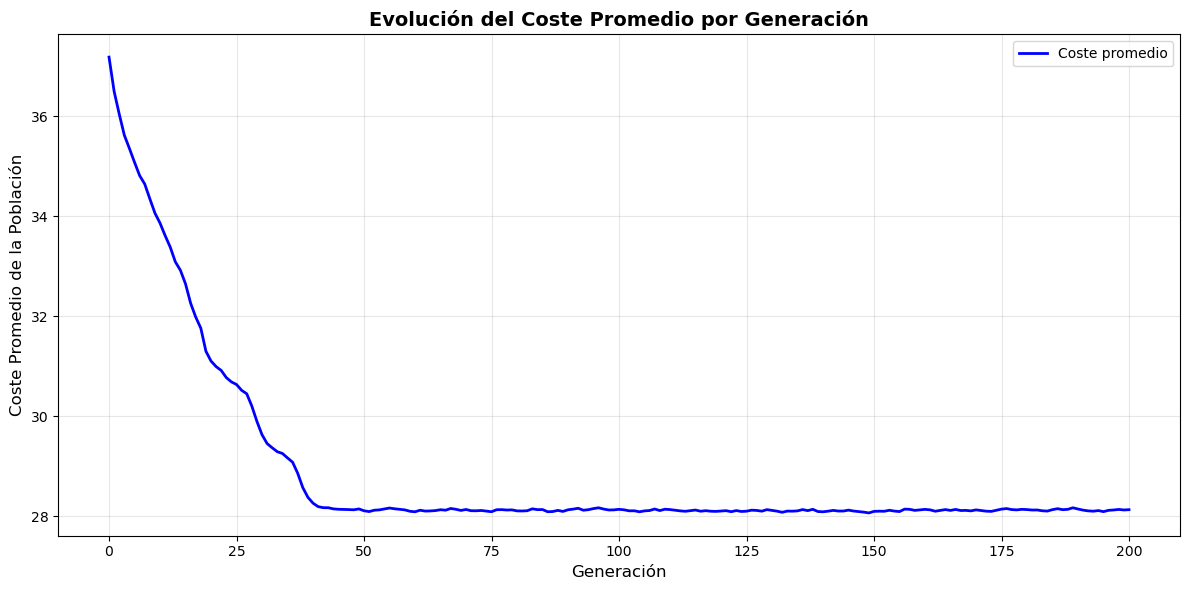

In [50]:
# Gráfica del coste promedio en función de la generación en la anterior ejecucion
plt.figure(figsize=(12, 6))

plt.plot(generaciones, 
         costes_promedio, 
         linewidth=2, 
         color='blue', 
         label='Coste promedio')

plt.xlabel('Generación', fontsize=12)
plt.ylabel('Coste Promedio de la Población', fontsize=12)
plt.title('Evolución del Coste Promedio por Generación', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Vemos que el pormedio de la distribucion de costes de las soluciones de la poblacion en cada generacion dva disminuyendo hasta alcanzar un limite, y que hasta ese punto las generaciones van mejorando y obteniendo mejores candidatos (con menor coste) hasta el limite. A mayores, vemos como se mejora la solucion inicial del Greedy+Busqueda local y ademas se ejecuta en un tiempo bastante reducido. Tambien vemos que para estos hiperparametros en realidad no son necearias mas de 60-75 generaciones para que el algoritmo converga a la solucion final.

Como el algoritmo genetico es estocastico, algunas veces al ejecutarlo obtenemos soluciones de 28 y otras obtenemos soluciones de 27, pues depende bastante de las soluciones iniciales con las que empieze a trabajar, y obviamnete de los hiperparametros que ajustemos. Por lo tanto lo que debemos hacer es ejecutar el algoritmo varias veces y quedarnos con la mejor

In [47]:
# Ejecutar múltiples veces el Algoritmo Genético
print("\n" + "=" * 80)
print("EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES")
print("=" * 80 + "\n")

num_ejecuciones = 10
resultados = []
mejor_global = float('inf')
mejor_solucion_global = None

for i in range(num_ejecuciones):
    solucion, coste, estadisticas_generaciones = algoritmo_genetico(
        A, 
        N=1000,
        mutacion=0.2,
        elitismo=0.8,
        generaciones=300,
        mostrar_prints=False
    )
    
    resultados.append(coste)

    if coste < mejor_global:
        mejor_solucion_global = solucion
        mejor_global = coste

    
# Mostrar resumen
print("\n" + "=" * 80)
print("RESUMEN DE RESULTADOS")
print("=" * 80)
print(f"\nCostes obtenidos en cada ejecución: {resultados}")
print(f"\nMejor coste global: {mejor_global}")
print(f"Peor coste: {max(resultados)}")
print(f"Coste promedio: {sum(resultados)/len(resultados):.2f}")
print(f"\nMejor solución: {mejor_solucion_global}")
print(f"¿Es válida?: {is_valid_schedule(mejor_solucion_global)}")


EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES


RESUMEN DE RESULTADOS

Costes obtenidos en cada ejecución: [28, 28, 27, 28, 28, 27, 28, 28, 28, 28]

Mejor coste global: 27
Peor coste: 28
Coste promedio: 27.80

Mejor solución: [2, 2, 4, 4, 4, 2, 4, 0, 4, 0, 0, 1, 2, 3, 4, 1, 3, 3, 3, 2, 0, 1, 3, 3, 1, 0, 2, 1, 0, 1]
¿Es válida?: True


In [ ]:
# Ejecutar múltiples veces el Algoritmo Genético
print("\n" + "=" * 80)
print("EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES")
print("=" * 80 + "\n")

num_ejecuciones = 10
resultados = []
mejor_global = float('inf')
mejor_solucion_global = None

for i in range(num_ejecuciones):
    solucion, coste, estadisticas_generaciones = algoritmo_genetico(
        A, 
        N=1000,
        mutacion=0.4,
        elitismo=0.6,
        generaciones=100,
        mostrar_prints=False
    )
    
    resultados.append(coste)

    if coste < mejor_global:
        mejor_solucion_global = solucion
        mejor_global = coste

    
# Mostrar resumen
print("\n" + "=" * 80)
print("RESUMEN DE RESULTADOS")
print("=" * 80)
print(f"\nCostes obtenidos en cada ejecución: {resultados}")
print(f"\nMejor coste global: {mejor_global}")
print(f"Peor coste: {max(resultados)}")
print(f"Coste promedio: {sum(resultados)/len(resultados):.2f}")
print(f"\nMejor solución: {mejor_solucion_global}")
print(f"¿Es válida?: {is_valid_schedule(mejor_solucion_global)}")


EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES


RESUMEN DE RESULTADOS

Costes obtenidos en cada ejecución: [28, 27, 27, 28, 28, 28, 28, 28, 28, 28]

Mejor coste global: 27
Peor coste: 28
Coste promedio: 27.80

Mejor solución: [2, 2, 0, 0, 0, 2, 2, 1, 2, 1, 1, 3, 0, 4, 0, 3, 4, 4, 4, 2, 1, 3, 4, 4, 3, 1, 0, 3, 1, 3]
¿Es válida?: True


In [ ]:
# Ejecutar múltiples veces el Algoritmo Genético
print("\n" + "=" * 80)
print("EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES")
print("=" * 80 + "\n")

num_ejecuciones = 10
resultados = []
mejor_global = float('inf')
mejor_solucion_global = None

for i in range(num_ejecuciones):
    solucion, coste, estadisticas_generaciones = algoritmo_genetico(
        A, 
        N=1000,
        mutacion=0.3,
        elitismo=0.4,
        generaciones=300,
        mostrar_prints=False
    )
    
    resultados.append(coste)

    if coste < mejor_global:
        mejor_solucion_global = solucion
        mejor_global = coste

    
# Mostrar resumen
print("\n" + "=" * 80)
print("RESUMEN DE RESULTADOS")
print("=" * 80)
print(f"\nCostes obtenidos en cada ejecución: {resultados}")
print(f"\nMejor coste global: {mejor_global}")
print(f"Peor coste: {max(resultados)}")
print(f"Coste promedio: {sum(resultados)/len(resultados):.2f}")
print(f"\nMejor solución: {mejor_solucion_global}")
print(f"¿Es válida?: {is_valid_schedule(mejor_solucion_global)}")


EJECUTANDO ALGORITMO GENÉTICO MÚLTIPLES VECES



### (*)Calcula la complejidad del algoritmo

Respuesta

Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta

In [10]:
import numpy as np

def get_random_data():
    np.random.seed(42)
    return np.random.randint(0, 2, size=(30, 10))   # 10 tomas y 6 actores

In [11]:
get_random_data()

array([[0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
       [0, 0, 0, 0, 1, 0, 1, 1, 1, 0],
       [1, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 0, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 0, 1, 1],
       [1, 1, 0, 1, 0, 1, 1, 1, 0, 1],
       [0, 1, 0, 1, 0, 0, 1, 0, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 0, 1, 1, 0, 1, 0, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1, 0, 1, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 1, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 1, 0, 0, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 1, 1, 1, 1, 0, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
       [1, 0, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0,

Aplica el algoritmo al juego de datos generado

Respuesta

Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

Respuesta